## baseline_08: Further interaction exploration
- Previous interaction using charge_weight aligned the .300blk's slope with the rest of the cartridges but exposed an intercept mismatch which led to a positive bias for that cartridge
- Using the same feature for the .223rem's interaction did not affect its slope mismatch
- This model will:
  - Keep the same interactions from the previous model
  - Add a new interaction based off the burn_rate_index feature

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ridge_dataset.csv")

In [3]:
df["charge_x_223_rem"] = df["charge_weight"] * (df["cartridge"] == "223_rem").astype(int)
df["charge_x_300_blk"] = df["charge_weight"] * (df["cartridge"] == "300_blk").astype(int)
df["burn_rate_x_223_rem"] = df["burn_rate_index"] * (df["cartridge"] == "223_rem").astype(int)
df["burn_rate_x_300_blk"] = df["burn_rate_index"] * (df["cartridge"] == "300_blk").astype(int)

numeric_features = [
    "charge_weight",
    "bullet_weight",
    "burn_rate_index",
    "charge_x_223_rem",
    "charge_x_300_blk",
    "burn_rate_x_223_rem",
    "burn_rate_x_300_blk"
]
categoric_features = ["cartridge"]
target = "velocity_fps"

X = df[numeric_features + categoric_features]
y = df[target].astype(float)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoric_features)
    ]
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

preprocessor.fit(X_train)

Train: (2789, 8)  Test: (698, 8)


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [11]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)
print(f"FLOOR MAE (test): {floor_mae:.2f}ft/s")

model = Pipeline([
    ("preprocess", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])


model.fit(X_train, y_train)
preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
print(f"MODEL MAE (test): {model_mae:.2f}ft/s")

FLOOR MAE (test): 255.79ft/s
MODEL MAE (test): 62.91ft/s


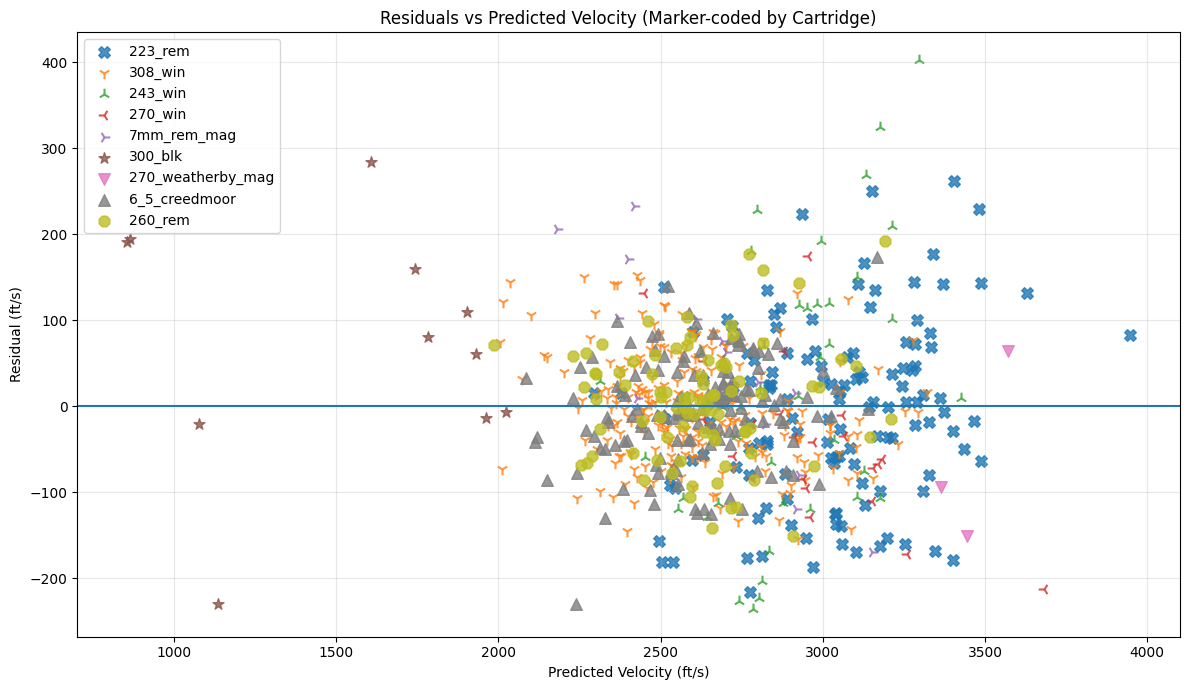

In [9]:
residuals = y_test.to_numpy() - preds

marker_map = {
    "223_rem": "X",
    "308_win": "1",
    "243_win": "2",
    "270_win": "3",
    "7mm_rem_mag": "4",
    "300_blk": "*",
    "270_weatherby_mag": "v",
    "6_5_creedmoor": "^",
    "260_rem": "8",
}

plt.figure(figsize=(12, 7))

for cartridge, marker in marker_map.items():
    mask = X_test["cartridge"] == cartridge
    plt.scatter(
        preds[mask],
        residuals[mask],
        marker=marker,
        s=70,
        alpha=0.8,
        label=cartridge
    )

plt.axhline(0,)
plt.xlabel("Predicted Velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("Residuals vs Predicted Velocity (Marker-coded by Cartridge)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of results:
Applying the additional interactions using the burn_rate_index feature has restored homoscedastic behavior to the residuals and has driven the model's MAE down even further (~63fps). This tells me that the model is now expressing correct geometry of the data and is trustworthy.

Overall, I am pleased with the direction of the project. We have consistently driven mean error down across the different models without sacrificing the integrity of the system despite introducing a significantly larger dataset that contains multiple subsets with their own unique behaviors.

## I feel that we have hit a milestone and are no longer in the "baseline phase."
This model has demonstrated its ability to provide a strong accurate prediction across a wide field of cartridge families while retaining trustworthyness. Further Ridge regression iterations will be refinements of this model which I feel is a strong candidate for production after some additional refinements. I do wish to explore other types of models but will be using this as the first reference model that all future models need to beat to be considered as production candidates.